In [ ]:
!pip install librosa soundfile matplotlib numpy pandas scikit-learn tensorflow seaborn tqdm fpdf2 streamlit pyngrok --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/AISH'
import os
os.makedirs(DRIVE_BASE, exist_ok=True)
print("Drive mounted. Base path:", DRIVE_BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Base path: /content/drive/MyDrive/AISH


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

INSTRUMENTS = ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
INSTRUMENT_NAMES = {
    'cel': 'Cello',           'cla': 'Clarinet',        'flu': 'Flute',
    'gac': 'Acoustic Guitar', 'gel': 'Electric Guitar',  'org': 'Organ',
    'pia': 'Piano',           'sax': 'Saxophone',        'tru': 'Trumpet',
    'vio': 'Violin',          'voi': 'Voice'
}
NUM_CLASSES = len(INSTRUMENTS)
print("Classes:", INSTRUMENTS)

Classes: ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']


In [ ]:
DATA_DIR = '/content/drive/MyDrive/AISH/IRMAS'   # your main folder

import os
import pandas as pd

records = []

folders = os.listdir(DATA_DIR)
print("Found folders:", folders)

for folder in folders:
    folder_path = os.path.join(DATA_DIR, folder)

    if not os.path.isdir(folder_path):
        continue

    for fname in os.listdir(folder_path):
        if fname.endswith('.wav'):
            records.append({
                'path': os.path.join(folder_path, fname),
                'label': folder   # ✅ label = folder name
            })

df = pd.DataFrame(records)

if df.empty:
    raise ValueError("❌ Still empty → dataset structure different. Show me screenshot.")

print("\n✅ Dataset Loaded!")
print(f"Total files: {len(df)}")

print("\n📊 Class distribution:")
print(df['label'].value_counts())

📂 Found folders: ['org', 'vio', 'gac', 'voi', 'flu', 'tru', 'gel', 'sax', 'pia', 'cel', 'cla']

✅ Dataset Loaded!
Total files: 6709

📊 Class distribution:
label
voi    778
gel    760
pia    721
org    682
gac    641
sax    626
vio    580
tru    577
cla    505
flu    451
cel    388
Name: count, dtype: int64


🎵 Detected Instruments: ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']

✅ Total files found: 6709

📊 Full dataset — samples per instrument:
cel       : 388
cla       : 505
flu       : 451
gac       : 641
gel       : 760
org       : 682
pia       : 721
sax       : 626
tru       : 577
vio       : 580
voi       : 778
TOTAL     : 6709

✅ Split Summary:
Train :  5367 (80.0%)
Val   :   671 (10.0%)
Test  :   671 (10.0%)

💾 Saved: train.csv | val.csv | test.csv

Instrument   Train     Val    Test   Total
--------------------------------------------------
cel            310      39      39     349
cla            404      51      50     455
flu            361      45      45     406
gac            513      64      64     577
gel            608      76      76     684
org            545      68      69     613
pia            577      72      72     649
sax            501      62      63     563
tru            462      58      57     520
vio            464      58   

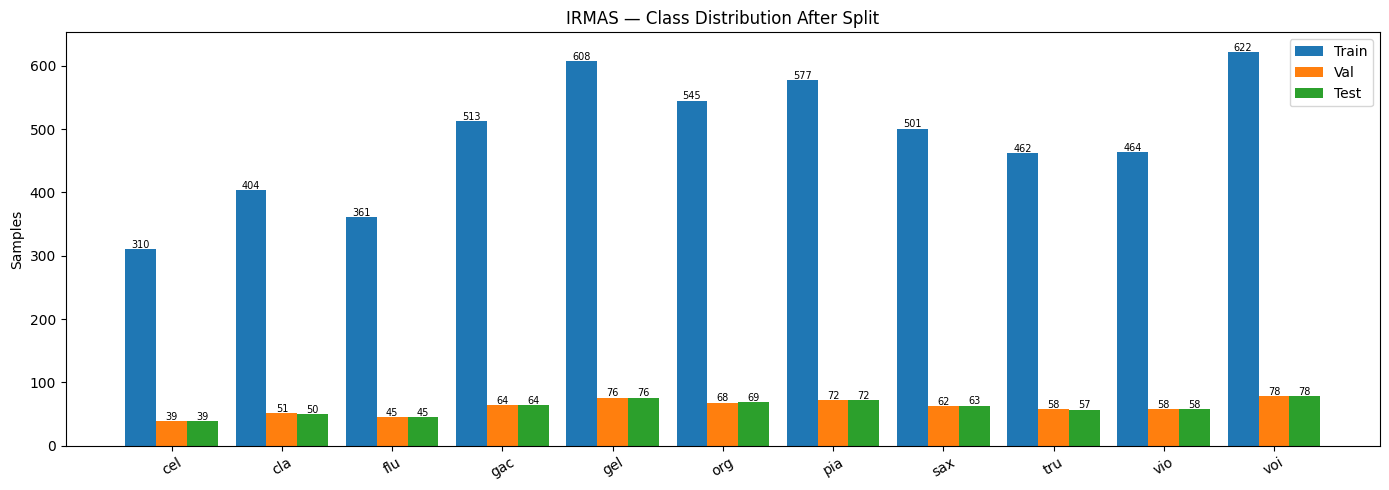

📸 Plot saved

🔍 Leakage Check:
Train ∩ Val  : 0
Train ∩ Test : 0
Val   ∩ Test : 0


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_DIR = os.path.join(DRIVE_BASE, 'IRMAS')   # ✅ your real folder

records = []

INSTRUMENTS = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

print("🎵 Detected Instruments:", INSTRUMENTS)

for inst in INSTRUMENTS:
    folder = os.path.join(DATA_DIR, inst)

    for fname in os.listdir(folder):
        if fname.endswith('.wav'):
            records.append({
                'path': os.path.join(folder, fname),
                'label': inst
            })

df = pd.DataFrame(records)

if df.empty:
    raise ValueError("❌ Dataset empty — check path")

print(f"\n✅ Total files found: {len(df)}")

print("\n📊 Full dataset — samples per instrument:")
class_counts = df['label'].value_counts().sort_index()
for inst in INSTRUMENTS:
    print(f"{inst:10s}: {class_counts[inst]}")
print(f"{'TOTAL':10s}: {len(df)}")

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print(f"\n✅ Split Summary:")
print(f"Train : {len(train_df):>5} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df):>5} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df):>5} ({len(test_df)/len(df)*100:.1f}%)")

SAVE_PATH = os.path.join(DRIVE_BASE, 'IRMAS_SPLIT')
os.makedirs(SAVE_PATH, exist_ok=True)

train_df.to_csv(SAVE_PATH + '/train.csv', index=False)
val_df.to_csv(SAVE_PATH   + '/val.csv',   index=False)
test_df.to_csv(SAVE_PATH  + '/test.csv',  index=False)

print("\n💾 Saved: train.csv | val.csv | test.csv")


def get_counts(split_df):
    return [len(split_df[split_df['label'] == inst]) for inst in INSTRUMENTS]

train_counts = get_counts(train_df)
val_counts   = get_counts(val_df)
test_counts  = get_counts(test_df)

print(f"\n{'Instrument':10s} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
print("-" * 50)

for i, inst in enumerate(INSTRUMENTS):
    tr = train_counts[i]
    vl = val_counts[i]
    ts = test_counts[i]
    print(f"{inst:10s} {tr:>7} {vl:>7} {ts:>7} {tr+vl:>7}")

print("-" * 50)
print(f"{'TOTAL':10s} {len(train_df):>7} {len(val_df):>7} {len(test_df):>7} {len(df):>7}")


x = np.arange(len(INSTRUMENTS))
width = 0.28

fig, ax = plt.subplots(figsize=(14,5))

b1 = ax.bar(x - width, train_counts, width, label='Train')
b2 = ax.bar(x,         val_counts,   width, label='Val')
b3 = ax.bar(x + width, test_counts,  width, label='Test')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 2, str(int(h)),
                ha='center', fontsize=7)

ax.set_title('IRMAS — Class Distribution After Split')
ax.set_ylabel('Samples')
ax.set_xticks(x)
ax.set_xticklabels(INSTRUMENTS, rotation=30)
ax.legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + '/class_distribution.png')
plt.show()

print("📸 Plot saved")

tr_set = set(train_df['path'])
vl_set = set(val_df['path'])
ts_set = set(test_df['path'])

print(f"\n🔍 Leakage Check:")
print(f"Train ∩ Val  : {len(tr_set & vl_set)}")
print(f"Train ∩ Test : {len(tr_set & ts_set)}")
print(f"Val   ∩ Test : {len(vl_set & ts_set)}")

File: /content/drive/MyDrive/AISH/IRMAS/pia/002__[pia][nod][cla]1382__2.wav
SR: 22050, Duration: 3.00s


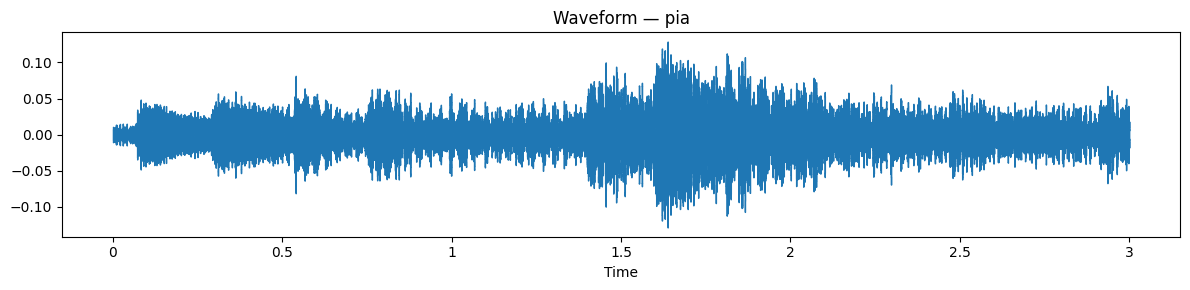

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

DATA_DIR = '/content/drive/MyDrive/AISH/IRMAS'

inst = 'pia'
folder = os.path.join(DATA_DIR, inst)

files = [f for f in os.listdir(folder) if f.endswith('.wav')]

if len(files) == 0:
    raise ValueError("❌ No wav files in this folder")

sample_file = os.path.join(folder, files[0])

# load audio
y, sr = librosa.load(sample_file, sr=22050, mono=True)

print(f"File: {sample_file}")
print(f"SR: {sr}, Duration: {len(y)/sr:.2f}s")

# plot waveform
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f'Waveform — {inst}')
plt.tight_layout()
plt.show()

In [ ]:
SR         = 22050
DURATION   = 3.0
N_FFT      = 2048
HOP_LENGTH = 512
N_MELS     = 128
FMIN       = 20
FMAX       = 8000
IMG_HEIGHT = 128
IMG_WIDTH  = 128
TOP_DB     = 80.0

DRIVE_BASE = '/content/drive/MyDrive/IRMAS'
TRAIN_DIR  = DRIVE_BASE + '/IRMAS-TrainData'
TEST_DIR   = DRIVE_BASE + '/IRMAS-TestData'
SPEC_DIR   = DRIVE_BASE + '/spectrograms'
MODEL_DIR  = DRIVE_BASE + '/models'

INSTRUMENTS  = ['cel','cla','flu','gac','gel','org','pia','sax','tru','vio','voi']
INSTRUMENT_NAMES = {
    'cel':'Cello','cla':'Clarinet','flu':'Flute','gac':'Acoustic Guitar',
    'gel':'Electric Guitar','org':'Organ','pia':'Piano','sax':'Saxophone',
    'tru':'Trumpet','vio':'Violin','voi':'Voice'
}
NUM_CLASSES = 11

import os
for d in [SPEC_DIR, MODEL_DIR, SPEC_DIR+'/train', SPEC_DIR+'/val', SPEC_DIR+'/test']:
    os.makedirs(d, exist_ok=True)
print("✅ Config ready.")

✅ Config ready.


In [ ]:
import librosa, numpy as np, cv2

def load_and_preprocess(filepath, sr=SR):
    y, orig_sr = librosa.load(filepath, sr=None, mono=False)
    if y.ndim > 1:
        y = librosa.to_mono(y)
    if orig_sr != sr:
        y = librosa.resample(y, orig_sr=orig_sr, target_sr=sr)
    y, _ = librosa.effects.trim(y, top_db=20)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    return y, sr

def segment_audio(y, sr=SR, duration=DURATION, hop_sec=1.5):
    seg_len = int(duration * sr)
    hop_len = int(hop_sec * sr)
    segments = []
    if len(y) < seg_len:
        y = np.pad(y, (0, seg_len - len(y)))
        segments.append(y)
    else:
        for start in range(0, len(y) - seg_len + 1, hop_len):
            segments.append(y[start:start + seg_len])
    return segments

def audio_to_melspectrogram(y, sr=SR):
    mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT,
                  hop_length=HOP_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    log_mel = librosa.power_to_db(mel, ref=np.max, top_db=TOP_DB)
    log_mel = (log_mel + TOP_DB) / TOP_DB
    img     = cv2.resize(log_mel, (IMG_WIDTH, IMG_HEIGHT))
    return img.astype(np.float32)

print("✅ Preprocessing functions defined.")

✅ Preprocessing functions defined.


File: /content/drive/MyDrive/AISH/IRMAS/pia/002__[pia][nod][cla]1382__2.wav
Duration: 2.98s
Segments: 1
Spec shape: (128, 128)
Min: 0.00, Max: 1.00


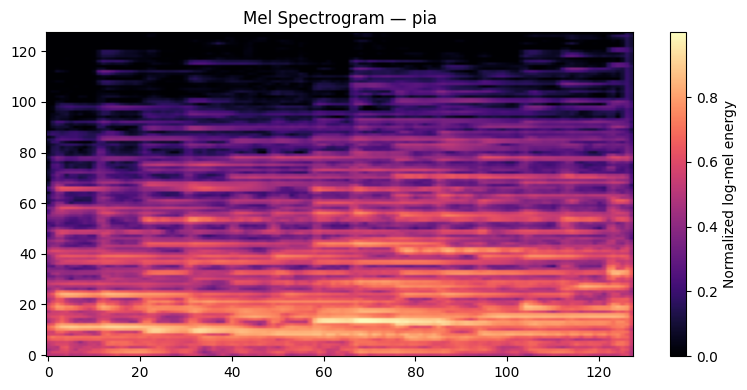

In [ ]:
import os
import matplotlib.pyplot as plt
DATA_DIR = '/content/drive/MyDrive/AISH/IRMAS'

inst = 'pia'
folder = os.path.join(DATA_DIR, inst)

files = [f for f in os.listdir(folder) if f.endswith('.wav')]

if len(files) == 0:
    raise ValueError("❌ No wav files found")

test_file = os.path.join(folder, files[0])

y, sr = load_and_preprocess(test_file)

print(f"File: {test_file}")
print(f"Duration: {len(y)/sr:.2f}s")

segs = segment_audio(y, sr)
print(f"Segments: {len(segs)}")

spec = audio_to_melspectrogram(segs[0], sr)

print(f"Spec shape: {spec.shape}")
print(f"Min: {spec.min():.2f}, Max: {spec.max():.2f}")

plt.figure(figsize=(8, 4))
plt.imshow(spec, aspect='auto', origin='lower', cmap='magma')
plt.colorbar(label='Normalized log-mel energy')
plt.title(f'Mel Spectrogram — {inst}')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import os

SPLIT_PATH = '/content/drive/MyDrive/AISH/IRMAS_SPLIT'

train_df = pd.read_csv(os.path.join(SPLIT_PATH, 'train.csv'))
val_df   = pd.read_csv(os.path.join(SPLIT_PATH, 'val.csv'))
test_df  = pd.read_csv(os.path.join(SPLIT_PATH, 'test.csv'))

print("✅ Loaded splits:")
print(f"Train: {len(train_df)}")
print(f"Val  : {len(val_df)}")
print(f"Test : {len(test_df)}")

✅ Loaded splits:
Train: 5367
Val  : 671
Test : 671


In [ ]:
import numpy as np
from tqdm import tqdm

def process_and_save(df, split_name):
    out_dir = os.path.join(SPEC_DIR, split_name)
    os.makedirs(out_dir, exist_ok=True)
    saved, errors = 0, 0
    specs, labels_list = [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        try:
            y, sr     = load_and_preprocess(row['path'])
            segs      = segment_audio(y, sr)
            label_idx = INSTRUMENTS.index(row['label'])
            label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
            label_vec[label_idx] = 1.0

            for i, seg in enumerate(segs[:3]):
                spec  = audio_to_melspectrogram(seg, sr)
                fname = f"{os.path.splitext(os.path.basename(row['path']))[0]}_seg{i}.npy"
                np.save(os.path.join(out_dir, fname), spec)
                specs.append(spec)
                labels_list.append(label_vec)
                saved += 1
        except Exception as e:
            errors += 1
            print(f"  ⚠️  Error: {row['path']} → {e}")

    X = np.array(specs)
    y_arr = np.array(labels_list)
    np.save(os.path.join(DRIVE_BASE, f'X_{split_name}.npy'), X)
    np.save(os.path.join(DRIVE_BASE, f'y_{split_name}.npy'), y_arr)
    print(f"{split_name}: {saved} spectrograms saved | Errors: {errors} | Shape: {X.shape}")

process_and_save(train_df, 'train')
process_and_save(val_df,   'val')
process_and_save(test_df,  'test')

Processing train: 100%|██████████| 5367/5367 [1:00:32<00:00,  1.48it/s]


✅ train: 5367 spectrograms saved | Errors: 0 | Shape: (5367, 128, 128)


Processing val: 100%|██████████| 671/671 [07:30<00:00,  1.49it/s]


✅ val: 671 spectrograms saved | Errors: 0 | Shape: (671, 128, 128)


Processing test: 100%|██████████| 671/671 [07:29<00:00,  1.49it/s]


✅ test: 671 spectrograms saved | Errors: 0 | Shape: (671, 128, 128)


In [ ]:
import numpy as np
import tensorflow as tf
print("TF:", tf.__version__)

X_train = np.load(DRIVE_BASE+'/X_train.npy')
y_train = np.load(DRIVE_BASE+'/y_train.npy')
X_val   = np.load(DRIVE_BASE+'/X_val.npy')
y_val   = np.load(DRIVE_BASE+'/y_val.npy')
X_test  = np.load(DRIVE_BASE+'/X_test.npy')
y_test  = np.load(DRIVE_BASE+'/y_test.npy')

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

TF: 2.19.0
X_train: (5367, 128, 128, 1) | y_train: (5367, 11)
X_val  : (671, 128, 128, 1)
X_test : (671, 128, 128, 1)


In [ ]:
def augment(x, y):
    def time_mask(spec):
        t  = tf.shape(spec)[1]
        t0 = tf.random.uniform((), 0, t//4, dtype=tf.int32)
        mw = tf.random.uniform((), 0, t//8, dtype=tf.int32)
        mask = tf.concat([
            tf.ones([IMG_HEIGHT, t0, 1]),
            tf.zeros([IMG_HEIGHT, mw, 1]),
            tf.ones([IMG_HEIGHT, tf.maximum(t-t0-mw, 0), 1])
        ], axis=1)
        return spec * tf.cast(mask[:, :t, :], spec.dtype)

    def freq_mask(spec):
        f0 = tf.random.uniform((), 0, IMG_HEIGHT//4, dtype=tf.int32)
        mh = tf.random.uniform((), 0, IMG_HEIGHT//8, dtype=tf.int32)
        mask = tf.concat([
            tf.ones([f0, IMG_WIDTH, 1]),
            tf.zeros([mh, IMG_WIDTH, 1]),
            tf.ones([tf.maximum(IMG_HEIGHT-f0-mh, 0), IMG_WIDTH, 1])
        ], axis=0)
        return spec * tf.cast(mask[:IMG_HEIGHT, :, :], spec.dtype)

    x = time_mask(x)
    x = freq_mask(x)
    x = x + tf.random.normal(tf.shape(x), stddev=0.01)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

BATCH_SIZE = 32

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(2000)
            .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

print("Datasets ready.")

✅ Datasets ready.


In [ ]:
from tensorflow.keras import layers, models, regularizers

def build_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), num_classes=NUM_CLASSES):
    inp = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(32,(3,3),padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x);  x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(64,(3,3),padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x);  x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x);  x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(256,(3,3),padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Dense head
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='sigmoid')(x)

    return models.Model(inp, out)

model = build_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 536,427 (2.05 MB)

 Trainable params: 535,275 (2.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc', multi_label=True)]
)
print("Model compiled.")

✅ Model compiled.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint_path = MODEL_DIR + '/best_model.h5'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]
print(" Callbacks set.")

✅ Callbacks set.


In [ ]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)
print("Training done.")

Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6353 - auc: 0.9239 - loss: 0.1736
Epoch 1: val_loss improved from 0.23514 to 0.22220, saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.6486 - auc: 0.9286 - loss: 0.1687 - val_accuracy: 0.5276 - val_auc: 0.9065 - val_loss: 0.2222 - learning_rate: 5.0000e-04
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6412 - auc: 0.9301 - loss: 0.1671
Epoch 2: val_loss did not improve from 0.22220
168/168 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.6460 - auc: 0.9309 - loss: 0.1662 - val_accuracy: 0.5171 - val_auc: 0.8860 - val_loss: 0.2320 - learning_rate: 5.0000e-04
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6594 - auc: 0.9284 - loss: 0.1671
Epoch 3: val_loss did not improve from 0.22220
168/168 ━━━━━━━━━━━━━━━━━━━━ 501s 3s/step - accuracy: 0.6577 - auc: 0.9312 - loss: 0.1657 - val_accuracy: 0.4799 - val_auc: 0.8786 - val_loss: 0.2957 - learning_rate: 5.0000e-04
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6723 - auc: 0.9387 - los


Epoch 8: finished saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.6952 - auc: 0.9477 - loss: 0.1467 - val_accuracy: 0.6289 - val_auc: 0.9369 - val_loss: 0.1884 - learning_rate: 2.5000e-04
Epoch 9/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7073 - auc: 0.9474 - loss: 0.1464
Epoch 9: val_loss did not improve from 0.18835
168/168 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.7116 - auc: 0.9496 - loss: 0.1445 - val_accuracy: 0.6259 - val_auc: 0.9319 - val_loss: 0.1922 - learning_rate: 2.5000e-04
Epoch 10/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7240 - auc: 0.9545 - loss: 0.1403
Epoch 10: val_loss improved from 0.18835 to 0.16444, saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.7187 - auc: 0.9532 - loss: 0.1411 - val_accuracy: 0.6602 - val_auc: 0.9456 - val_loss: 0.1644 - learning_rate: 2.5000e-04
Epoch 11/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7217 - auc: 0.9523 - loss: 0.1400
Epoch 11: val_loss improved from 0.16444 to 0.14790, saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5



Epoch 11: finished saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.7185 - auc: 0.9512 - loss: 0.1411 - val_accuracy: 0.6870 - val_auc: 0.9490 - val_loss: 0.1479 - learning_rate: 2.5000e-04
Epoch 12/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7281 - auc: 0.9528 - loss: 0.1386
Epoch 12: val_loss did not improve from 0.14790
168/168 ━━━━━━━━━━━━━━━━━━━━ 445s 3s/step - accuracy: 0.7166 - auc: 0.9526 - loss: 0.1408 - val_accuracy: 0.6781 - val_auc: 0.9479 - val_loss: 0.1616 - learning_rate: 2.5000e-04
Epoch 13/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7186 - auc: 0.9515 - loss: 0.1403
Epoch 13: val_loss did not improve from 0.14790
168/168 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.7203 - auc: 0.9536 - loss: 0.1391 - val_accuracy: 0.5693 - val_auc: 0.9048 - val_loss: 0.2511 - learning_rate: 2.5000e-04
Epoch 14/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7271 - auc: 0.9550


Epoch 18: finished saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.7472 - auc: 0.9601 - loss: 0.1288 - val_accuracy: 0.7228 - val_auc: 0.9522 - val_loss: 0.1464 - learning_rate: 1.2500e-04
Epoch 19/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7534 - auc: 0.9603 - loss: 0.1281
Epoch 19: val_loss improved from 0.14639 to 0.14466, saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5



Epoch 19: finished saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.7555 - auc: 0.9621 - loss: 0.1273 - val_accuracy: 0.7124 - val_auc: 0.9535 - val_loss: 0.1447 - learning_rate: 1.2500e-04
Epoch 20/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7547 - auc: 0.9644 - loss: 0.1246
Epoch 20: val_loss did not improve from 0.14466
168/168 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - accuracy: 0.7567 - auc: 0.9631 - loss: 0.1244 - val_accuracy: 0.7183 - val_auc: 0.9506 - val_loss: 0.1515 - learning_rate: 1.2500e-04
Epoch 21/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7727 - auc: 0.9664 - loss: 0.1202
Epoch 21: val_loss did not improve from 0.14466
168/168 ━━━━━━━━━━━━━━━━━━━━ 511s 3s/step - accuracy: 0.7636 - auc: 0.9642 - loss: 0.1233 - val_accuracy: 0.7004 - val_auc: 0.9435 - val_loss: 0.1602 - learning_rate: 1.2500e-04
Epoch 22/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7531 - auc: 0.9632


Epoch 25: finished saving model to /content/drive/MyDrive/IRMAS/models/best_model.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - accuracy: 0.7770 - auc: 0.9682 - loss: 0.1174 - val_accuracy: 0.7258 - val_auc: 0.9544 - val_loss: 0.1406 - learning_rate: 6.2500e-05
Epoch 26/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7667 - auc: 0.9677 - loss: 0.1187
Epoch 26: val_loss did not improve from 0.14063
168/168 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.7762 - auc: 0.9690 - loss: 0.1165 - val_accuracy: 0.7481 - val_auc: 0.9495 - val_loss: 0.1531 - learning_rate: 6.2500e-05
Epoch 27/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7906 - auc: 0.9696 - loss: 0.1133
Epoch 27: val_loss did not improve from 0.14063
168/168 ━━━━━━━━━━━━━━━━━━━━ 520s 3s/step - accuracy: 0.7811 - auc: 0.9692 - loss: 0.1150 - val_accuracy: 0.7094 - val_auc: 0.9503 - val_loss: 0.1612 - learning_rate: 6.2500e-05
Epoch 28/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7697 - auc: 0.9674

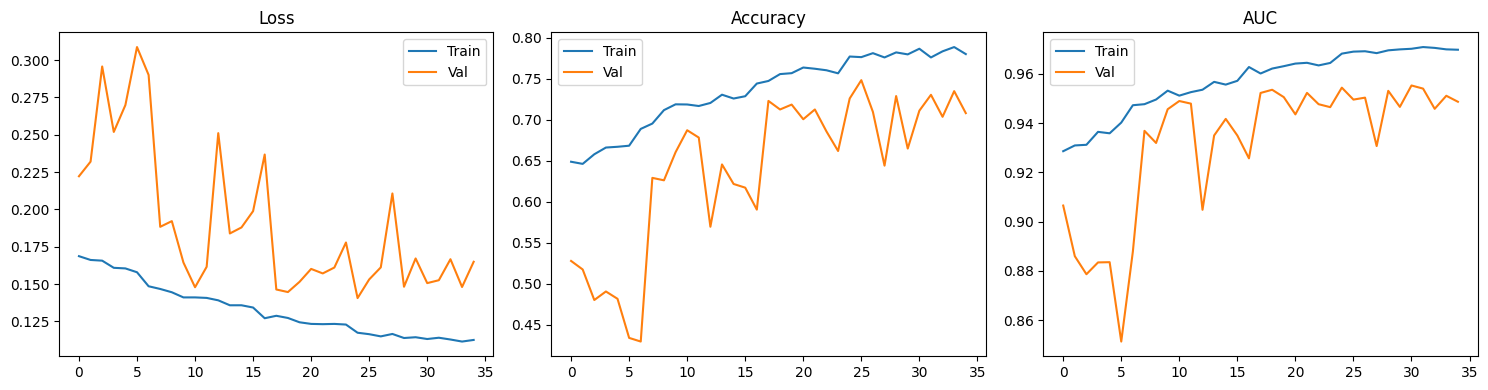

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes,
    ['loss','accuracy','auc'], ['Loss','Accuracy','AUC']):
    ax.plot(history.history[metric],       label='Train')
    ax.plot(history.history['val_'+metric],label='Val')
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig(DRIVE_BASE+'/training_curves.png', dpi=150)
plt.show()

In [ ]:
import numpy as np, tensorflow as tf
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

model  = tf.keras.models.load_model(MODEL_DIR+'/best_model.h5')
X_test = np.load(DRIVE_BASE+'/X_test.npy')[..., np.newaxis]
y_test = np.load(DRIVE_BASE+'/y_test.npy')

THRESHOLD = 0.5
y_prob = model.predict(X_test, verbose=0)
y_pred = (y_prob >= THRESHOLD).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=INSTRUMENTS, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

         cel       0.68      0.44      0.53        39
         cla       0.85      0.44      0.58        50
         flu       0.82      0.51      0.63        45
         gac       0.70      0.88      0.78        64
         gel       0.73      0.79      0.76        76
         org       0.98      0.81      0.89        69
         pia       0.94      0.83      0.88        72
         sax       0.73      0.35      0.47        63
         tru       0.73      0.79      0.76        57
         vio       0.56      0.66      0.60        58
         voi       0.94      0.81      0.87        78

   micro avg       0.78      0.69      0.73       671
   macro avg       0.79      0.66      0.70       671
weighted avg       0.80      0.69      0.72       671
 samples avg       0.69      0.69      0.69       671



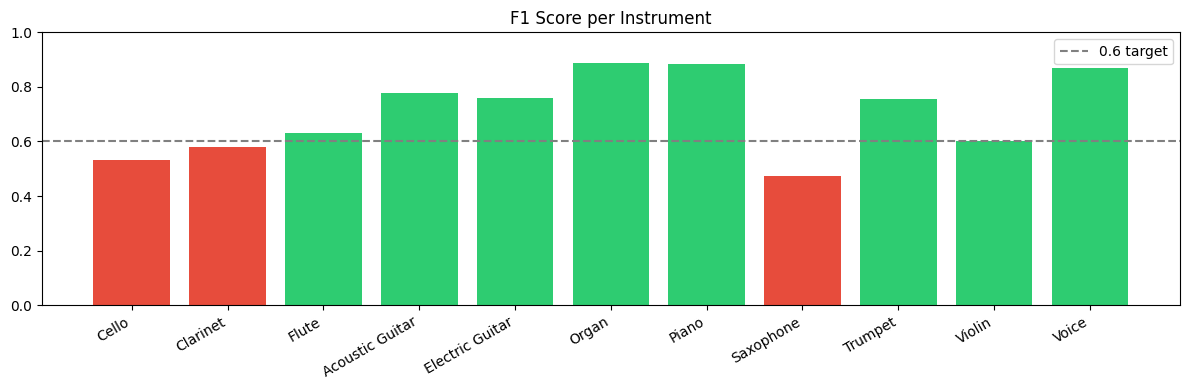

In [ ]:
f1s = f1_score(y_test, y_pred, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#2ecc71' if f > 0.6 else '#e74c3c' for f in f1s]
ax.bar([INSTRUMENT_NAMES[i] for i in INSTRUMENTS], f1s, color=colors)
ax.axhline(0.6, color='gray', linestyle='--', label='0.6 target')
ax.set_ylim(0,1); ax.set_title('F1 Score per Instrument')
ax.set_xticklabels([INSTRUMENT_NAMES[i] for i in INSTRUMENTS], rotation=30, ha='right')
ax.legend(); plt.tight_layout()
plt.savefig(DRIVE_BASE+'/f1_scores.png', dpi=150); plt.show()

In [ ]:
import os, json

DATA_DIR = '/content/drive/MyDrive/AISH/IRMAS'

inst = 'pia'
folder = os.path.join(DATA_DIR, inst)

# safe file selection
files = [f for f in os.listdir(folder) if f.endswith('.wav')]
if len(files) == 0:
    raise ValueError("❌ No wav files found")

sample = os.path.join(folder, files[0])

result = predict_instruments(sample, model)

print(json.dumps(result, indent=2))

{
  "file": "002__[pia][nod][cla]1382__2.wav",
  "detected_instruments": [
    "pia"
  ],
  "confidence_scores": {
    "cel": 0.0,
    "cla": 0.0,
    "flu": 0.0,
    "gac": 0.0023,
    "gel": 0.0004,
    "org": 0.0,
    "pia": 0.9993,
    "sax": 0.0,
    "tru": 0.0,
    "vio": 0.0,
    "voi": 0.0
  },
  "threshold_used": 0.5
}


In [ ]:
import datetime

def export_json(result, out_path=None):
    result['exported_at'] = datetime.datetime.now().isoformat()
    out_path = out_path or DRIVE_BASE+'/prediction_result.json'
    with open(out_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f"✅ JSON saved: {out_path}")

export_json(result)

✅ JSON saved: /content/drive/MyDrive/IRMAS/prediction_result.json


In [ ]:
from fpdf import FPDF

def export_pdf(result, out_path=None):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font('Helvetica','B',16)
    pdf.cell(0,12,'Instrument Recognition Report',ln=True,align='C')
    pdf.set_font('Helvetica','',10)
    pdf.cell(0,8,f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}",ln=True,align='C')
    pdf.ln(4)
    pdf.set_font('Helvetica','B',12)
    pdf.cell(0,10,f"File: {result['file']}",ln=True)
    pdf.set_font('Helvetica','',10)
    pdf.cell(0,8,f"Threshold: {result['threshold_used']}",ln=True)
    pdf.ln(4)
    pdf.set_font('Helvetica','B',12)
    pdf.cell(0,10,'Detected Instruments:',ln=True)
    pdf.set_font('Helvetica','',11)
    for inst in result['detected_instruments']:
        pdf.cell(0,8,f"  [PRESENT]  {INSTRUMENT_NAMES[inst]}",ln=True)
    pdf.ln(4)
    pdf.set_font('Helvetica','B',12)
    pdf.cell(0,10,'Confidence Scores:',ln=True)
    pdf.set_font('Helvetica','',10)
    for inst, score in sorted(result['confidence_scores'].items(), key=lambda x:-x[1]):
        bar = '#' * int(score*30)
        pdf.cell(0,7,f"  {INSTRUMENT_NAMES[inst]:20s} {score:.3f}  {bar}",ln=True)
    out_path = out_path or DRIVE_BASE+'/prediction_report.pdf'
    pdf.output(out_path)
    print(f"✅ PDF saved: {out_path}")

export_pdf(result)

✅ PDF saved: /content/drive/MyDrive/IRMAS/prediction_report.pdf


NEW CODE FOR NEW APP.PY

In [124]:
!pkill -f streamlit
!pkill -f cloudflared

In [125]:
import subprocess, time

proc = subprocess.Popen(
    ['streamlit','run','/content/drive/MyDrive/IRMAS/app.py',
     '--server.port=8501',
     '--server.address=0.0.0.0',
     '--server.headless=true']
)

time.sleep(10)

In [127]:
!curl http://127.0.0.1:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig

In [128]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://127.0.0.1:8501

2026-03-31T02:12:12Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-31T02:12:12Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-31T02:12:17Z INF +--------------------------------------------------------------------------------------------+
2026-03-31T02:12:17Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-31T02:12:17Z INF |  https://pupils-laden-yale-apparatus.trycloudflare.com